In [9]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from maploc.demo import Demo, read_input_image

# Increasing the number of rotations increases the accuracy but requires more GPU memory.
# The highest accuracy is achieved with num_rotations=360
# but num_rotations=64~128 is often sufficient.
# To reduce the memory usage, we can reduce the tile size in the next cell.
device = "cuda"
demo = Demo(load_from_hub=False, experiment_or_path="prerelease/prerelease.ckpt", num_rotations=64, device=device)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[2024-09-20 20:04:29 maploc INFO] Could not find any location for address 'Service Canada Center, vancouver.'
[2024-09-20 20:04:29 maploc INFO] Using prior location from EXIF.
[2024-09-20 20:04:29 maploc INFO] Could not call PerspectiveFields, maybe install gradio_client?


[2024-09-20 20:04:29 maploc INFO] Calling the OpenStreetMap API...
100%|██████████| 9/9 [00:00<00:00, 215.41it/s]
[2024-09-20 20:04:30 maploc INFO] Calling the OpenStreetMap API...
100%|██████████| 9/9 [00:00<00:00, 386.77it/s]


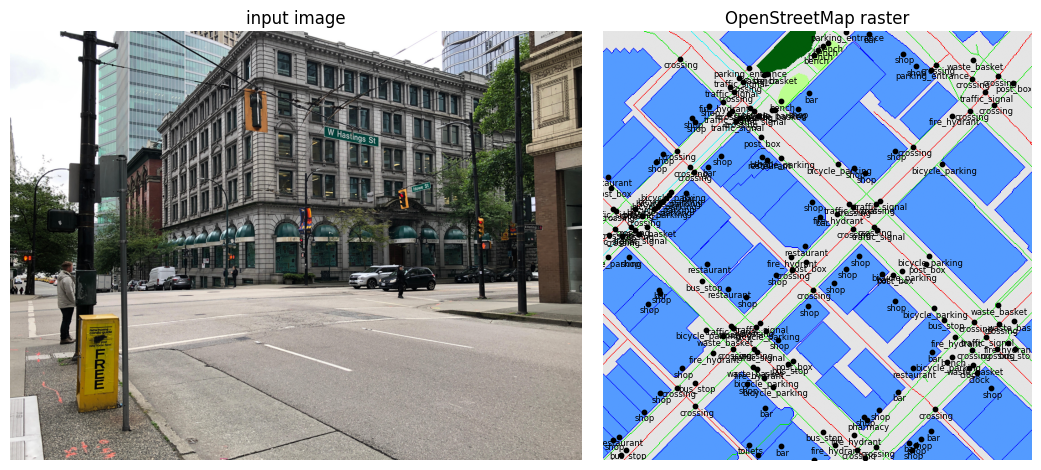

In [28]:
# no EXIF data: provide a coarse location prior as address
# image_path = "assets/query_zurich_1.jpeg"
# prior_address = "ETH CAB Zurich"
# Try out these other queries!
image_path = "assets/query_vancouver_3.jpeg"
prior_address = "Vancouver Waterfront Station"
prior_address = "Service Canada Center, vancouver"

# image_path = "assets/query_vancouver_2.JPG"
# image_path = "assets/query_vancouver_3.JPG"
# prior_address = None # here we load the location prior from the exif

image, camera, roll_pitch, proj, bbox, prior_latlon = read_input_image(
    image_path,
    prior_address=prior_address,
    tile_size_meters=128,  # try 64, 256, etc.
)

# Show the query area in an interactive map
from maploc.osm.viz import GeoPlotter

plot = GeoPlotter(zoom=16)
plot.points(prior_latlon[:2], "red", name="location prior", size=10)
plot.bbox(proj.unproject(bbox), "blue", name="map tile")
plot.fig.show("notebook")

# Query OpenStreetMap for this area
from maploc.osm.tiling import TileManager

ppm_list = demo.config.data.pixel_per_meter
canvas = {}
for i,z_max in enumerate(demo.config.data.z_max):

    ppm = ppm_list[i]
    tiler = TileManager.from_bbox(proj, bbox + 10, ppm)
    canvas[z_max] = tiler.query(bbox)

# Show the inputs to the model: image and raster map
from maploc.osm.viz import Colormap, plot_nodes
from maploc.utils.viz_2d import plot_images

depth32m = demo.config.data.z_max[0] # corresponds to finer ppm
map_viz = Colormap.apply(canvas[depth32m].raster)
plot_images([image, map_viz], titles=["input image", "OpenStreetMap raster"])
plot_nodes(1, canvas[depth32m].raster[2], fontsize=6, size=10)

In [29]:
from maploc.utils.viz_localization import (
    likelihood_overlay,
    plot_dense_rotations,
    add_circle_inset,
)
from maploc.utils.viz_2d import features_to_RGB

# Run the inference
tile_T_cam_max, map_T_cam_max, prob, neural_map, image, semantic_map, pred = demo.localize(
    image, camera, canvas, roll_pitch=roll_pitch
)
image = image.squeeze()

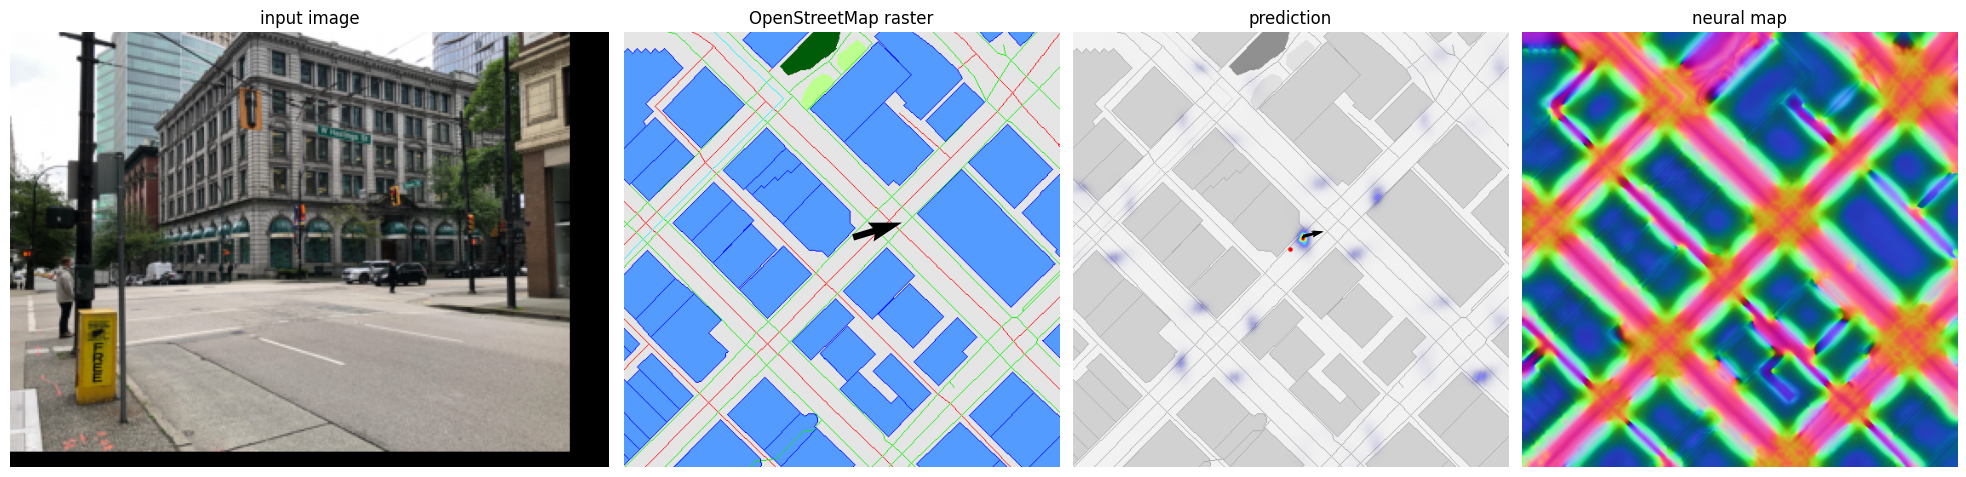

In [30]:
import numpy as np
import torch

depth32m = demo.config.data.z_max[0] # corresponds to finer ppm
# Get the memory-layout map raster from localize() output
map_viz = Colormap.apply(semantic_map[depth32m].cpu())

# Visualize the predictions
overlay = likelihood_overlay(prob.squeeze(0).numpy().max(-1), map_viz.mean(-1, keepdims=True))
(neural_map_rgb,) = features_to_RGB(neural_map.squeeze(0).numpy())

overlay, neural_map_rgb, map_viz = [
    np.swapaxes(x, 0, 1) for x in (overlay, neural_map_rgb, map_viz)
]

from maploc.utils.viz_localization import plot_pose, plot_bev
from maploc.utils.wrappers import Transform2D

map_T_cam_max = Transform2D.to_pixels(tile_T_cam_max, 1 / 2)

plot_images([image.permute(1,2,0), map_viz, overlay, neural_map_rgb], titles=["input image", "OpenStreetMap raster", "prediction", "neural map"],
            origins=["upper", "lower", "lower", "lower"])
axes = plt.gcf().axes
ax = axes[2]
ax.scatter(*canvas[32.0].to_uv(bbox.center), s=5, c="red")
plot_dense_rotations(ax, prob.squeeze(0), w=0.005, s=1 / 25)

plot_pose(
        [1],
        map_T_cam_max.t.squeeze(0),
        map_T_cam_max.angle.squeeze(0),
        c="k",
        refactored=True,
        dot=False,
        s=1/60
        )
# add_circle_inset(ax, uv) # still broken

# BEV overlay. broken
# (bev,) = features_to_RGB(pred[128.0]["features_bev"].squeeze(0).numpy(), masks=[pred[128.0]["valid_bev"].squeeze(0).numpy()])
# increase 128m bev's resolution
# bev = torch.nn.functional.interpolate(
#                 torch.from_numpy(bev).unsqueeze(0).moveaxis(-1, -3), scale_factor=4, mode="bilinear"
#             ).moveaxis(-3, -1).squeeze(0).numpy()
# axes[1].images[0].set_interpolation("none")
# plot_bev(bev, uv=map_T_cam_max.t.squeeze(0), yaw=map_T_cam_max.angle.squeeze(0), zorder=10, ax=axes[2])

plt.show("notebook")

# Plot as interactive figure
bbox_latlon = proj.unproject(canvas[32.0].bbox)
plot = GeoPlotter(zoom=16.5)
plot.raster(np.flipud(map_viz), bbox_latlon, opacity=0.5)
overlay = likelihood_overlay(prob.squeeze(0).numpy().max(-1))
overlay = np.swapaxes(overlay, 0, 1)
plot.raster(np.flipud(overlay), proj.unproject(bbox))
plot.points(prior_latlon[:2], "red", name="location prior", size=10)
uv = map_T_cam_max.t
uv[...,-1] = canvas[32.0].h - uv[...,-1]
plot.points(proj.unproject(canvas[32.0].to_xy(map_T_cam_max.t)), "black", name="argmax", size=10)
plot.bbox(bbox_latlon, "blue", name="map tile")
plot.fig.show()

In [ ]:
# Visualize BEV + Confidence

titles = []
bevs = []
for z_max in demo.config.data.z_max:
    
    mask_bev = pred[z_max]["valid_bev"].squeeze(0)
    (bev,) = features_to_RGB(pred[z_max]["features_bev"].squeeze(0).numpy(), masks=[mask_bev.numpy()])
    conf_q = torch.log(pred[z_max]["bev"]["confidence"])
    conf_q = conf_q.masked_fill(~mask_bev, np.nan)
    bevs.append(np.swapaxes(bev, 0, 1))
    bevs.append(np.swapaxes(conf_q.squeeze(0), 0, 1))
    titles.append(f"BEV depth: {z_max}m")
    titles.append(f"BEV Confidence: {z_max}m")

plot_images(bevs, titles, origins=['lower', 'lower']*2, cmaps='jet')

In [ ]:
# Visualize Image Features and Max Score
(fine_im_feat,) = features_to_RGB(pred["features_image"][0, :128, ...].numpy())
(coarse_im_feat,) = features_to_RGB(pred["features_image"][0, 128:, ...].numpy())

max_scores = []
for z_max in demo.config.data.z_max:
    scales_scores = pred[z_max]["pixel_scales"].squeeze(0)
    log_prob = torch.nn.functional.log_softmax(scales_scores, dim=-1)
    max_scores.append(log_prob.max(-1).values.exp())


plot_images([fine_im_feat, coarse_im_feat, *max_scores], 
            titles=["Fine Image Features", "Coarse Image Features", "Fine Max Scale Score (red=high)", "Coarse Max Scale Score (red=high)"],
            origins=["upper", "upper", "upper", "upper"],
            cmaps="jet")
